In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
import datetime
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles_f')
import funciones_aux_bootstrap_f_r as fab

# Bootstrap por Submuestra de Votos - Método 1

**Nota**: Este notebook es parte del **Paso 2** del flujo de ejecución del proyecto.

**Requisitos previos**:
- Haber ejecutado: `Codigos/Codigo_creacion_base_analisis/Creacion_base_analsis.ipynb`
- Archivo de entrada: `Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv`

**Salida**:
- Resultados guardados en: `Bases finales rep/Bootstrap votos/Metodo 1/`

Para más información sobre el flujo completo, consultar el `README.md` del repositorio.

Este método de bootstrap (bayesiano) por votos consiste en lo siguiente

1. Se muestrea $n$ casillas.
2. De las $n$ casillas se muestrean $k$ votos.
3. Con estos $k$ votos se calculan los pesos Dirichlet para cada población (en total son 1000).
4. Se completan $1000$ poblaciones.
5. Con las poblaciones se obtienen la estimación puntual.

Se repite este proceso para $l$ bootstraps (normalmente son 1000) y con estos bootstraps se obtienen todas las métricas (errores, tamaño de los intervalos, coberturas, etc).

In [2]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [3]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Sin estratificar

In [4]:
def bootstrap_votos_simple(df, num_boot: int=1000, n_sample=None, n_vot_sub=2000, semilla=1):

    est_punt_list=[]

    inter_list=[]

    # Número total de votos
    n_votos=int(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())


    for i in range(num_boot):

        # Semilla para que el código sea reproducible
        rng = np.random.default_rng((i+1)+(num_boot*semilla))

        df_stra_sam = df.sample(n=n_sample, random_state= rng)

        df_stra_sam=np.array(df_stra_sam[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Votos por candidato en la muestra
        #n_votos_cand=df_stra_sam.sum(0).astype(int)

        # Semilla para que el código sea reproducible
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+1)))

        # Submuestra de votos (en este caso son 2000)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        votos_subm=rng.multivariate_hypergeometric(colors=df_stra_sam.sum(0).astype(int), nsample=n_vot_sub)

        # Semilla para que el código sea reproducible
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+2)))

        # Los pesos de la distribución Dirichlet
        pesos_bootstrap=rng.dirichlet(votos_subm, 1000)

        # Semilla para que el código sea reproducible
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+3)))

        # Simulamos las 1000 poblaciones de votos
        votos_sim=rng.multinomial(n=n_votos,  pvals=pesos_bootstrap)

        # Obtenemos las proporciones de los votos
        array_res=(votos_sim)/n_votos

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        #print(i)
        
    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)

    return array_inter_prob,array_est_punt


In [10]:
# Para medir cuanto tiempo se tarda en correr
# Boostrap por votos
inter_prob_v, est_punt_v=bootstrap_votos_simple(df_act_yuc_i, num_boot=1000, n_sample=350, n_vot_sub=15000, semilla=5)

350


In [10]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit bootstrap_votos_simple(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=5000)

250
250
250
250
250
250
250
250
1.24 s ± 135 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
# Guardamos las bases
df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=20000)

In [13]:
df_can_cob_v

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,679,0.679,20000
1,RENAN_BARRERA_CONCHA,676,0.676,20000
2,VIDA_ARAVARI_GOMEZ_HERRERA,810,0.810,20000
3,VOTOS_NULOS_CAND_NO_REGIS,902,0.902,20000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,833,0.833,20000


In [14]:
df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':['median','mean']})

Longitud_intervalo          
                                        median      mean
Candidato                                               
JOAQUIN_DIAZ_MENA                     0.016031  0.016035
RENAN_BARRERA_CONCHA                  0.015820  0.015834
VIDA_ARAVARI_GOMEZ_HERRERA            0.006027  0.006030
VOTOS_NULOS_CAND_NO_REGIS             0.004639  0.004640
YAMIL_JASMIN_LOPEZ_MANRIQUE           0.002297  0.002303

In [12]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.023007,20000.0
std,288.819436,0.013948,0.0
min,1.000000,0.001148,20000.0
2.5%,25.975000,0.004865,20000.0
50%,500.500000,0.020348,20000.0
97.5%,975.025000,0.058966,20000.0
max,1000.000000,0.099548,20000.0


In [13]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.497658,0.588763,0.091105,0.546197,0.515125,JOAQUIN_DIAZ_MENA,0.031071,20000,0.933
1,2,0.485114,0.569721,0.084607,0.527967,0.515125,JOAQUIN_DIAZ_MENA,0.012841,20000,0.933
2,3,0.503929,0.586214,0.082285,0.545419,0.515125,JOAQUIN_DIAZ_MENA,0.030294,20000,0.933
3,4,0.459804,0.548642,0.088838,0.502344,0.515125,JOAQUIN_DIAZ_MENA,0.012781,20000,0.933
4,5,0.468864,0.555498,0.086634,0.511559,0.515125,JOAQUIN_DIAZ_MENA,0.003566,20000,0.933
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.009498,0.033051,0.023553,0.019788,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001679,20000,0.925
4996,997,0.009061,0.034651,0.025590,0.020148,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001319,20000,0.925
4997,998,0.012607,0.037701,0.025094,0.023844,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.002377,20000,0.925
4998,999,0.016871,0.046415,0.029544,0.030024,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.008557,20000,0.925


In [14]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]
df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v]["Longitud_intervalo"].describe()

count    1000.000000
mean        0.086956
std         0.002498
min         0.078975
25%         0.085254
50%         0.086927
75%         0.088623
max         0.094038
Name: Longitud_intervalo, dtype: float64

In [128]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]

In [129]:
# Candidato con menor cobertura
candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

In [130]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.013322,250.0
std,288.819436,0.007878,0.0
min,1.000000,0.001436,250.0
2.5%,25.975000,0.002791,250.0
50%,500.500000,0.011537,250.0
97.5%,975.025000,0.030890,250.0
max,1000.000000,0.051513,250.0


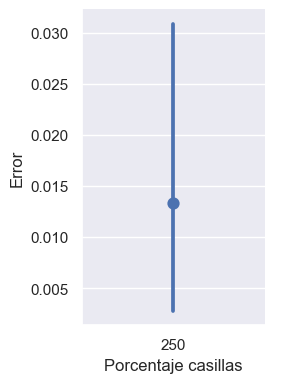

In [131]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [132]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.493772,0.537227,0.043455,0.516363,0.515125,JOAQUIN_DIAZ_MENA,0.001238,250,0.886
1,2,0.471874,0.515637,0.043763,0.493922,0.515125,JOAQUIN_DIAZ_MENA,0.021204,250,0.886
2,3,0.490195,0.536270,0.046075,0.513713,0.515125,JOAQUIN_DIAZ_MENA,0.001412,250,0.886
3,4,0.478045,0.520293,0.042248,0.499337,0.515125,JOAQUIN_DIAZ_MENA,0.015789,250,0.886
4,5,0.477104,0.521367,0.044263,0.499749,0.515125,JOAQUIN_DIAZ_MENA,0.015376,250,0.886
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.018280,0.031710,0.013429,0.024469,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.003002,250,0.930
4996,997,0.015120,0.027430,0.012310,0.020969,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000498,250,0.930
4997,998,0.020001,0.034218,0.014216,0.026938,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.005471,250,0.930
4998,999,0.016995,0.029279,0.012284,0.022991,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001524,250,0.930


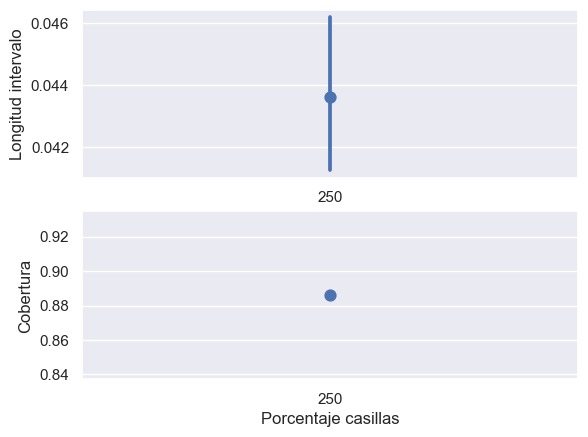

In [133]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


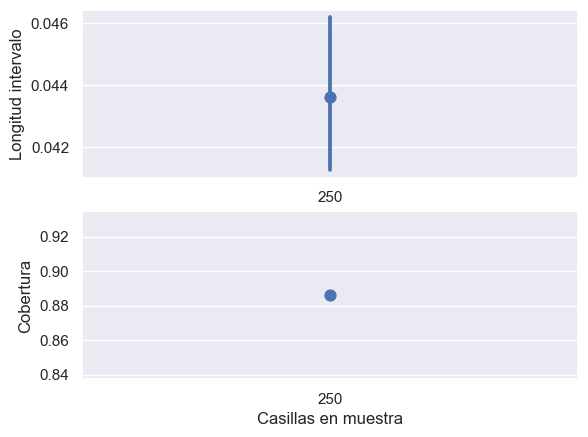

In [134]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Casillas en muestra', ylabel='Longitud intervalo');
ax_2.set(xlabel='Casillas en muestra', ylabel='Cobertura');

### Bootstraps con distintas muestras de casillas y submuestras de votos

In [78]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
#submuestra_votos = [500, 1000, 1500, 2000, 3000, 4000]
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_se=pd.DataFrame()

# Contador para el for
k=0

for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Boostrap por votos (sin estratificar)
        inter_prob_v, est_punt_v=bootstrap_votos_simple(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv, semilla=k+1)
        # Calculamos las métricas
        df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=mc)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_se.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Las métricas para el error máximo
        df_boostraps_votos_se.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v[df_can_cob_v["Candidato"]==candidato_int_m_l]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_se.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_v[df_metr_boot_v["Candidato"]==candidato_int_m_l]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men_v
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_se.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v[df_can_cob_v["Candidato"]==candidato_cober_men_v]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_se.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_v[df_metr_boot_v["Candidato"]==candidato_cober_men_v]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_se.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)

100
Muestra casillas: 100 Submuestra votos: 500
100
Muestra casillas: 100 Submuestra votos: 1000
100
Muestra casillas: 100 Submuestra votos: 2000
100
Muestra casillas: 100 Submuestra votos: 5000
100
Muestra casillas: 100 Submuestra votos: 10000
100
Muestra casillas: 100 Submuestra votos: 20000
150
Muestra casillas: 150 Submuestra votos: 500
150
Muestra casillas: 150 Submuestra votos: 1000
150
Muestra casillas: 150 Submuestra votos: 2000
150
Muestra casillas: 150 Submuestra votos: 5000
150
Muestra casillas: 150 Submuestra votos: 10000
150
Muestra casillas: 150 Submuestra votos: 20000
200
Muestra casillas: 200 Submuestra votos: 500
200
Muestra casillas: 200 Submuestra votos: 1000
200
Muestra casillas: 200 Submuestra votos: 2000
200
Muestra casillas: 200 Submuestra votos: 5000
200
Muestra casillas: 200 Submuestra votos: 10000
200
Muestra casillas: 200 Submuestra votos: 20000
250
Muestra casillas: 250 Submuestra votos: 500
250
Muestra casillas: 250 Submuestra votos: 1000
250
Muestra casill

In [79]:
df_boostraps_votos_se

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,100,500,0.005386,0.021258,0.063249,JOAQUIN_DIAZ_MENA,0.904,0.082385,0.087068,0.092355,JOAQUIN_DIAZ_MENA,0.904,0.082385,0.087068,0.092355,0.904,0.914,0.916,0.938,0.908
1,100,1000,0.004712,0.018606,0.049738,JOAQUIN_DIAZ_MENA,0.864,0.058117,0.061699,0.065619,RENAN_BARRERA_CONCHA,0.854,0.057203,0.060818,0.064492,0.864,0.854,0.894,0.937,0.903
2,100,2000,0.003235,0.014939,0.042026,JOAQUIN_DIAZ_MENA,0.795,0.041190,0.043556,0.046247,RENAN_BARRERA_CONCHA,0.766,0.040577,0.042995,0.045621,0.795,0.766,0.832,0.915,0.871
3,100,5000,0.002548,0.012566,0.035163,JOAQUIN_DIAZ_MENA,0.638,0.025967,0.027593,0.029294,RENAN_BARRERA_CONCHA,0.626,0.025798,0.027270,0.029011,0.638,0.626,0.739,0.892,0.795
4,100,10000,0.002123,0.011357,0.033686,JOAQUIN_DIAZ_MENA,0.521,0.018489,0.019575,0.020771,RENAN_BARRERA_CONCHA,0.505,0.018165,0.019331,0.020497,0.521,0.505,0.619,0.841,0.686
5,100,20000,0.002143,0.011728,0.030550,JOAQUIN_DIAZ_MENA,0.383,0.013125,0.013908,0.014773,RENAN_BARRERA_CONCHA,0.373,0.012899,0.013730,0.014584,0.383,0.373,0.461,0.800,0.544
6,150,500,0.005229,0.021237,0.058694,JOAQUIN_DIAZ_MENA,0.939,0.082181,0.086953,0.092164,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.894,0.000000,0.011069,0.019097,0.939,0.915,0.919,0.932,0.894
7,150,1000,0.003878,0.015362,0.047742,JOAQUIN_DIAZ_MENA,0.890,0.058142,0.061502,0.065376,JOAQUIN_DIAZ_MENA,0.890,0.058142,0.061502,0.065376,0.890,0.894,0.907,0.943,0.925
8,150,2000,0.003090,0.012891,0.037597,JOAQUIN_DIAZ_MENA,0.844,0.040996,0.043618,0.046324,RENAN_BARRERA_CONCHA,0.842,0.040513,0.043136,0.045688,0.844,0.842,0.874,0.935,0.871
9,150,5000,0.002310,0.010446,0.030551,JOAQUIN_DIAZ_MENA,0.694,0.026107,0.027606,0.029278,RENAN_BARRERA_CONCHA,0.689,0.025639,0.027262,0.028936,0.694,0.689,0.823,0.908,0.822


In [80]:
# Guardamos en un csv
df_boostraps_votos_se.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 1/Distintas_muestras_submuestras_bootstrap_votos_met_1_sin_est_f_1.csv")

## Estratificado (por distrito)

In [6]:
# Versión función
def boot_votos_estratificado(df_act_yuc_i, num_boot: int=1000, n_sample=None, n_vot_sub=2000, semilla = 1):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas votos hay por distrito
    array_frec_est=np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).reset_index(drop=True).astype(int)["TOTAL"])

    # Número de poblaciones
    n_boot=1000

    # Los valores distintos de los distritos
    val_dist=df_act_yuc_i["DISTRITO"].sort_values().unique()

    for i in range(num_boot):


        # Hacemos el muestreo de tamaño n_sample de las casilas estratificado por distrito
        df_stra_sam=fab.muestreo_estratificado_mej(df_act_yuc_i, ["DISTRITO"], sample_size=n_sample, semilla=i+1+(num_boot*semilla))

        # Guardamos en un numpy array el dataframe de la muestra
        array_muest=np.array(df_stra_sam[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Corrección porque el muestreo estratificado es de votos
        # Porcentaje del total de votos por estrato (distrito)
        array_pesos_normalizados_dist=np.array(df_stra_sam.groupby('DISTRITO').agg({'TOTAL':'sum'}).div(df_stra_sam["TOTAL"].sum()).sort_index()["TOTAL"])

        # Obtenemos los totales de las proporciones para cada estrato (distrito)
        totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_sub).astype(int)

        # Los porcentajes de cada distrito en la submuestra de votos
        array_pesos_normalizados_sub=totales_prop_est/totales_prop_est.sum()

        # Submuestra de votos por distrito (estrato)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        votos_subm_d=[np.random.default_rng(index+((i+1)+(num_boot*(semilla+1)))).multivariate_hypergeometric(colors=array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), nsample=totales_prop_est[val-1]) for index, val in enumerate(val_dist)]

        # Vector de pesos de la distribución Dirichlet

        # Hay que arreglar la función para que pueda aceptar valores con alfa igual a cero (que tengan probabilidad 0)
        vectores_dir=[fab.f_a(xi,n_boot, semilla=index+((i+1)+(num_boot*(semilla+2)))) for index, xi in enumerate(votos_subm_d)]

        # Donde se van a guardar los resultados
        array_res=np.zeros((n_boot,5))

        # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
        for k in val_dist:

            # Semilla para las muestras de la Multinomial
            rng_2 = np.random.default_rng((num_boot*(semilla+3))+(i+1+k))
            
            # Total de votos de la muestra simulada (utilizando una multinomial)
            votos_sim=rng_2.multinomial(n=array_frec_est[k-1],  pvals=vectores_dir[k-1])

            # Guardamos todo en un array con las estimaciones (se van sumando las iteraciones para alcnazar el 100%)
            array_res=array_res+(votos_sim/votos_sim.sum(1)[0]*array_pesos_normalizados_sub[k-1])

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))

        # Estimaciones puntuales (del bootstrap)
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)

    #print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)
    
    return array_inter_prob,array_est_punt


In [67]:
inter_prob_v_est, est_punt_v_est=boot_votos_estratificado(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=1000, semilla=1)

In [9]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit boot_votos_estratificado(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=5000)

11.4 s ± 286 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [64]:
# Cálculamos las métricas
df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=2000)

In [65]:
df_can_cob_v_est

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,927,0.927,2000
1,RENAN_BARRERA_CONCHA,932,0.932,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,926,0.926,2000
3,VOTOS_NULOS_CAND_NO_REGIS,930,0.930,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,918,0.918,2000


In [8]:
# Candidato con intervalo más largo
df_inter_lar_v_est=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v_est["Porcenta_tama"]=250
candidato_mas_largo_v_est=df_inter_lar_v_est[df_inter_lar_v_est["Longitud_intervalo"]==df_inter_lar_v_est["Longitud_intervalo"].max()]["Candidato"].values[0]

In [9]:
# Candidato con menor cobertura
candidato_cober_men_v_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

In [66]:
df_error_max_v_est.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.016654,2000.0
std,288.819436,0.009386,0.0
min,1.000000,0.000723,2000.0
2.5%,25.975000,0.004282,2000.0
50%,500.500000,0.014764,2000.0
97.5%,975.025000,0.039014,2000.0
max,1000.000000,0.056791,2000.0


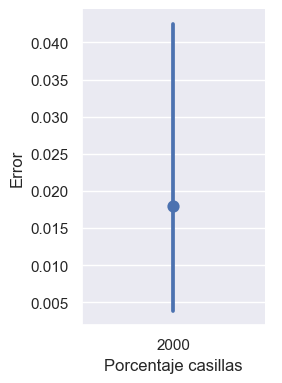

In [11]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v_est, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [12]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v_est=df_metr_boot_v_est.drop(columns="Cobertura").merge(df_can_cob_v_est[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v_est

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.477064,0.535293,0.058229,0.506471,0.515125,JOAQUIN_DIAZ_MENA,0.008654,2000,0.887
1,2,0.467302,0.525819,0.058517,0.496292,0.515125,JOAQUIN_DIAZ_MENA,0.018833,2000,0.887
2,3,0.513954,0.572825,0.058870,0.543139,0.515125,JOAQUIN_DIAZ_MENA,0.028014,2000,0.887
3,4,0.482323,0.542296,0.059973,0.512608,0.515125,JOAQUIN_DIAZ_MENA,0.002517,2000,0.887
4,5,0.498739,0.558585,0.059847,0.528584,0.515125,JOAQUIN_DIAZ_MENA,0.013458,2000,0.887
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.016958,0.036276,0.019317,0.025826,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.004359,2000,0.942
4996,997,0.011617,0.028651,0.017034,0.019112,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.002355,2000,0.942
4997,998,0.011493,0.026944,0.015451,0.018025,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.003442,2000,0.942
4998,999,0.016114,0.035274,0.019160,0.025599,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.004132,2000,0.942


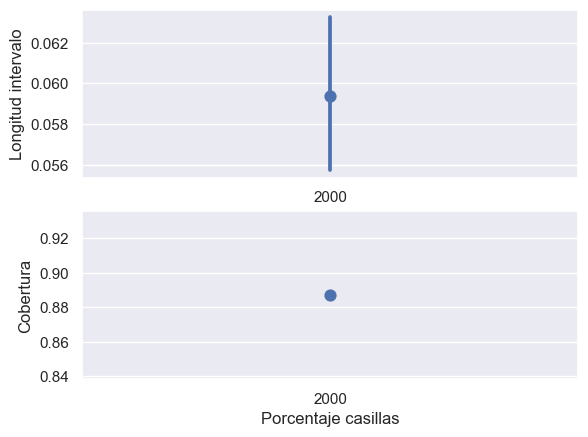

In [13]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


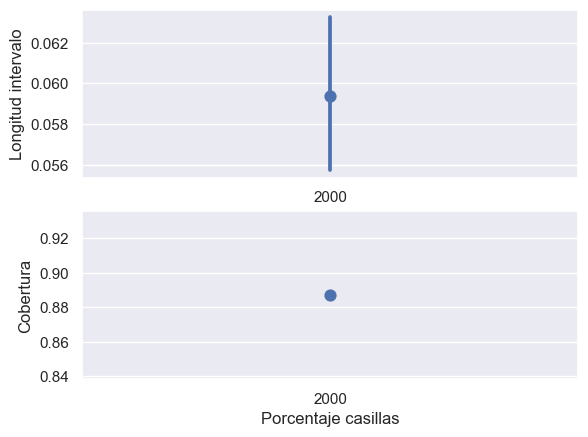

In [14]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

### Bootstraps con distintas muestras de casillas y submuestras de votos

In [82]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_ec=pd.DataFrame()

# Contador para el for
k=0

# Hacemos los for sobre el tamaño de las muestras y submuestras
for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Para medir cuanto tiempo se tarda en correr
        loop_time = time.time()
        # Boostrap por votos (estratificado)
        inter_prob_v_est, est_punt_v_est=boot_votos_estratificado(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv)

        # Calculamos las métricas
        df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=mc)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_ec.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Las métricas para el error máximo
        df_boostraps_votos_ec.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v_est["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_est_m_l=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_est_m_l
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_int_est_m_l]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_ec.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_v_est[df_metr_boot_v_est["Candidato"]==candidato_int_est_m_l]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_est_men_v=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_est_men_v
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_ec.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_cober_est_men_v]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_ec.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_v_est[df_metr_boot_v_est["Candidato"]==candidato_cober_est_men_v]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_ec.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v_est.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)
        print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  

# Lo guardamos en otra base copia por si sin querer pongo a correr el código
df_boostraps_votos_ec_f=df_boostraps_votos_ec.copy()

Muestra casillas: 100 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 8.461609840393066
Muestra casillas: 100 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 9.232874870300293
Muestra casillas: 100 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 10.497835874557495
Muestra casillas: 100 Submuestra votos: 5000
Tiempo que tarda correr una iteración del for 10.555238246917725
Muestra casillas: 100 Submuestra votos: 10000
Tiempo que tarda correr una iteración del for 11.153828859329224
Muestra casillas: 100 Submuestra votos: 20000
Tiempo que tarda correr una iteración del for 11.54113483428955
Muestra casillas: 150 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 8.26150107383728
Muestra casillas: 150 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 8.884875059127808
Muestra casillas: 150 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 9.893789768218994
Muestra casillas:

In [83]:
df_boostraps_votos_ec_f

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,100,500,0.005423,0.019495,0.055754,JOAQUIN_DIAZ_MENA,0.911,0.076984,0.081911,0.087329,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.886,0.000000,0.011678,0.018993,0.911,0.909,0.915,0.922,0.886
1,100,1000,0.003838,0.015259,0.042669,JOAQUIN_DIAZ_MENA,0.896,0.055796,0.059271,0.062766,RENAN_BARRERA_CONCHA,0.888,0.054967,0.058385,0.062154,0.896,0.888,0.905,0.914,0.907
2,100,2000,0.003044,0.012976,0.035223,JOAQUIN_DIAZ_MENA,0.856,0.039905,0.042275,0.044956,RENAN_BARRERA_CONCHA,0.836,0.039171,0.041674,0.044237,0.856,0.836,0.867,0.910,0.882
3,100,5000,0.002506,0.010168,0.028879,JOAQUIN_DIAZ_MENA,0.742,0.025316,0.026910,0.028611,RENAN_BARRERA_CONCHA,0.713,0.025089,0.026544,0.028114,0.742,0.713,0.773,0.889,0.784
4,100,10000,0.002228,0.009189,0.027675,JOAQUIN_DIAZ_MENA,0.620,0.018042,0.019127,0.020266,RENAN_BARRERA_CONCHA,0.603,0.017782,0.018832,0.020069,0.620,0.603,0.640,0.853,0.698
5,100,20000,0.002017,0.008716,0.026219,JOAQUIN_DIAZ_MENA,0.485,0.012733,0.013592,0.014452,RENAN_BARRERA_CONCHA,0.460,0.012650,0.013401,0.014263,0.485,0.460,0.490,0.787,0.559
6,150,500,0.005354,0.020439,0.056494,JOAQUIN_DIAZ_MENA,0.919,0.077092,0.081947,0.087324,VIDA_ARAVARI_GOMEZ_HERRERA,0.898,0.022483,0.030682,0.037561,0.919,0.921,0.898,0.914,0.907
7,150,1000,0.003646,0.014869,0.041717,JOAQUIN_DIAZ_MENA,0.906,0.055520,0.059313,0.062602,JOAQUIN_DIAZ_MENA,0.906,0.055520,0.059313,0.062602,0.906,0.919,0.928,0.920,0.914
8,150,2000,0.002947,0.011686,0.032177,JOAQUIN_DIAZ_MENA,0.865,0.039853,0.042186,0.044977,JOAQUIN_DIAZ_MENA,0.865,0.039853,0.042186,0.044977,0.865,0.876,0.882,0.918,0.886
9,150,5000,0.002361,0.009630,0.025810,JOAQUIN_DIAZ_MENA,0.783,0.025413,0.026967,0.028759,RENAN_BARRERA_CONCHA,0.764,0.025065,0.026555,0.028196,0.783,0.764,0.810,0.920,0.834


In [85]:
# Guardamos la base en un csv
df_boostraps_votos_ec_f.to_csv("/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 1/Distintas_muestras_submuestras_bootstrap_votos_met_1_estratificado_f_1.csv")